# Práctica 2.2. Implementación de clase RNN
## Bogdan Kaleb García Rivera MIA-3

Objetivo: Implementar la clase RNN basada en VanillaRNN de la práctica 2.1 y realizar el entrenamiento de la base de datos Sentiment and Emotion Analysis Dataset.




Anteriormente se realizaron los calculos de una red neuronal simple (https://github.com/BogdanRivera/ai-repository/blob/main/NLP/Procesamiento_de_lenguaje_natural/rnn_from_scratch/1_rnn_operations.ipynb), con la que contiene métodos como Forward, Backward y actualización de pesos. Recordando que se debe usar las funciones de tangente hiperbólica para la salida de la capa oculta y sigmoide para la salida final.



Creación de la clase.

La clase contiene todas las operaciones del notebook realizadas con anterioridad. Para validar los resultados pasados se ajustó la red para que inicializara los pesos de manera aleatoria o con los pesos iniciales anteriores del notebook.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical

class SimpleRNN:
    def __init__(self, vocab_size=None, embedding_dim=32, hidden_dim=64, output_dim=2, random_init=False):
        self.random_init = random_init

        if self.random_init:
            self.vocab_size = vocab_size
            self.embedding_dim = embedding_dim
            self.hidden_dim = hidden_dim
            self.output_dim = output_dim
            self.E = np.random.randn(vocab_size, embedding_dim) * 0.1
            self.W_x = np.random.randn(hidden_dim, embedding_dim) * 0.1
            self.U   = np.random.randn(hidden_dim, hidden_dim) * 0.1
            self.b_h = np.zeros(hidden_dim)
            self.W_y = np.random.randn(output_dim, hidden_dim) * 0.1
            self.b_y = np.zeros(output_dim)
            self.h_0 = np.zeros(hidden_dim)
        else:
            self.embedding_dim = 3
            self.hidden_dim = 2
            self.W_x = np.array([[0.5, 0.6, 0.7], [0.8, 0.9, 1.0]])
            self.U   = np.array([[0.1, 0.2], [0.3, 0.4]])
            self.b_h = np.array([0.1, 0.2])
            self.W_y = np.array([[0.2, 0.3], [0.4, 0.5]])
            self.b_y = np.array([0.3, 0.4])
            self.h_0 = np.array([0.0, 0.0])

        self.inputs = None
        self.hidden_states = None
        self.outputs = None
        self.entradas_embeddings = None

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):

        if self.random_init:
            self.inputs = x
            vector_s = [self.E[token_id] for token_id in x]
            self.entradas_embeddings = vector_s
        else:
            self.inputs = np.array(x)
            vector_s = self.inputs

        h_prev = self.h_0
        self.hidden_states = [h_prev]
        self.outputs = []
        for x_t in vector_s:
            op_h = self.W_x @ x_t + self.U @ h_prev + self.b_h
            h_t = np.tanh(op_h)
            self.hidden_states.append(h_t)
            op_y = self.W_y @ h_t + self.b_y
            y_t = self.sigmoid(op_y)
            self.outputs.append(y_t)
            h_prev = h_t
        return self.outputs[-1]

    def backward(self, y_true):
        y_true = np.array(y_true)
        grad_Wx = np.zeros_like(self.W_x)
        grad_U  = np.zeros_like(self.U)
        grad_bh = np.zeros_like(self.b_h)
        grad_E = np.zeros_like(self.E) if self.random_init else None

        dy_t = self.outputs[-1] - y_true
        grad_Wy = np.outer(dy_t, self.hidden_states[-1])
        grad_by = dy_t
        dh_next = self.W_y.T @ dy_t

        vector_s = self.entradas_embeddings if self.random_init else self.inputs

        for t in reversed(range(len(vector_s))):
            x_t = vector_s[t]
            h_t = self.hidden_states[t+1]
            h_prev = self.hidden_states[t]

            dpre_h = (1 - h_t**2) * dh_next

            if self.random_init:
                token_id = self.inputs[t]
                grad_x_t = self.W_x.T @ dpre_h
                np.add.at(grad_E, token_id, grad_x_t)

            grad_Wx += np.outer(dpre_h, x_t)
            grad_U  += np.outer(dpre_h, h_prev)
            grad_bh += dpre_h
            dh_next = self.U.T @ dpre_h

        return {"Gwy": grad_Wy, "Gby": grad_by, "Gw": grad_Wx, "Gu": grad_U, "Gbh": grad_bh, "Ge": grad_E}

    def update_weights(self, gradients, alpha):
        self.W_y -= alpha * gradients["Gwy"]
        self.b_y -= alpha * gradients["Gby"]
        self.W_x -= alpha * gradients["Gw"]
        self.U   -= alpha * gradients["Gu"]
        self.b_h -= alpha * gradients["Gbh"]

        if self.random_init and gradients["Ge"] is not None:
            self.E -= alpha * gradients["Ge"]

    def train(self, input_data, y_true, alpha, epochs):
        y_true_np = np.array(y_true)
        for epoch in range(epochs):
            y_pred = self.forward(input_data)
            loss = np.mean((y_pred - y_true_np)**2)
            gradients = self.backward(y_true_np)
            self.update_weights(gradients, alpha)
            if (epoch + 1) % 20 == 0:
                print(f"Época {epoch + 1}/{epochs}, Pérdida (MSE): {loss:.6f}")

Probando la clase con los valores de la práctica anterior.

In [ ]:
if __name__ == "__main__":
    embeddings = [
        [0.1, 0.2, 0.3],
        [0.4, 0.5, 0.6],
        [0.7, 0.8, 0.9]
    ]
    y_true = [1, 0]
    alpha = 0.1

    rnn = SimpleRNN()
    y_final = rnn.forward(embeddings)

    print("Salida (y_t):", np.round(y_final, 3))
    print("-" * 40)

    gradients_np = rnn.backward(y_true)

    print("Gradientes finales:")
    print("  GW: \n", np.round(gradients_np["Gw"], 6))
    print("  GU: \n", np.round(gradients_np["Gu"], 6))
    print("  Gb_h: \n", np.round(gradients_np["Gbh"], 6))
    print("-" * 40)

    rnn.update_weights(gradients_np, alpha)

    print(f"\nPesos de W_x: \n")
    print(np.round(rnn.W_x, 4))

    print(f"\nPesos de U:\n")
    print(np.round(rnn.U, 4))

    print(f"\nPesos de b_h:\n")
    print(np.round(rnn.b_h, 4))

Salida (y_t): [0.688 0.782]
----------------------------------------
Gradientes finales:
  GW: 
 [[0.017393 0.019938 0.022482]
 [0.002203 0.002556 0.00291 ]]
  GU: 
 [[0.020608 0.023948]
 [0.002576 0.003035]]
  Gb_h: 
 [0.025445 0.003537]
----------------------------------------

Pesos de W_x: 

[[0.4983 0.598  0.6978]
 [0.7998 0.8997 0.9997]]

Pesos de U:

[[0.0979 0.1976]
 [0.2997 0.3997]]

Pesos de b_h:

[0.0975 0.1996]


Es de observarse que se llega a los mismos resultados.

Una vez visto que la red funciona, el siguiente paso es probar la red con un conjunto de datos. Para este caso se hará uso del dataset "Sentiment and Emotion Analysis Dataset": https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset.

## 1. Exploración de los datos y limpieza.

Carga de los datos

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = kagglehub.dataset_download("kushagra3204/sentiment-and-emotion-analysis-dataset")

print("Path to dataset files:", path)

df = pd.read_csv('/kaggle/input/sentiment-and-emotion-analysis-dataset/archive/combined_sentiment_data.csv')
print("Primeras 5 filas del dataset: \n",df.head())


Using Colab cache for faster access to the 'sentiment-and-emotion-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-and-emotion-analysis-dataset
Primeras 5 filas del dataset: 
                                             sentence sentiment
0  So there is no way for me to plug it in here i...  negative
1                        Good case, Excellent value.  positive
2                             Great for the jawbone.  positive
3  Tied to charger for conversations lasting more...  negative
4                                  The mic is great.  positive


Visualizando los valores únicos de la columna objetivo.

In [ ]:
print("Valores únicos: ",df['sentiment'].value_counts().unique)

Valores únicos:  <bound method Series.unique of sentiment
positive    1679
negative    1630
Name: count, dtype: int64>


Se observa que existe un balanceo considerable con respecto a la variable objetivo.

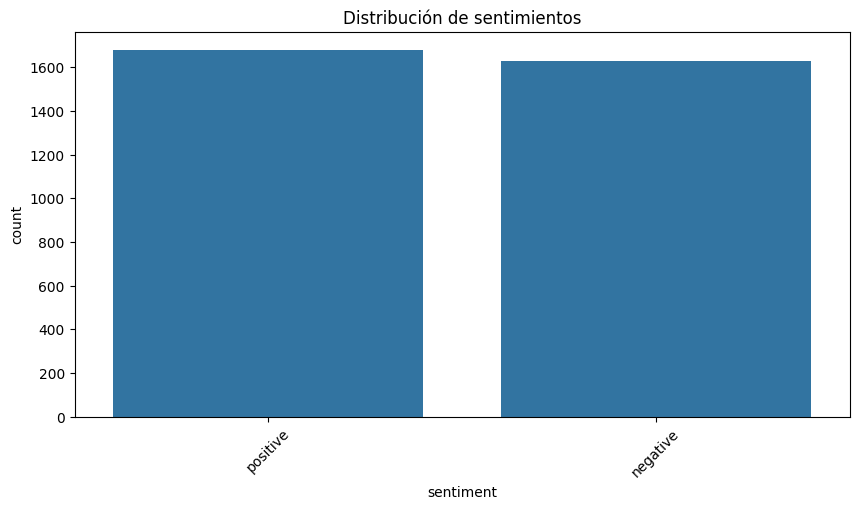

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index)
plt.title('Distribución de sentimientos')
plt.xticks(rotation=45)
plt.show()

Visualizando cual es la longitud por cada elemento y la longitud máxima en general.

In [ ]:
df['longitud_texto'] = df['sentence'].apply(len)
df.head()

,sentence,sentiment,longitud_texto
0,So there is no way for me to plug it in here i...,negative,82
1,"Good case, Excellent value.",positive,27
2,Great for the jawbone.,positive,22
3,Tied to charger for conversations lasting more...,negative,79
4,The mic is great.,positive,17


In [ ]:
print("La longitud máxima en los textos es: ",max(df['longitud_texto']))

La longitud máxima en los textos es:  479


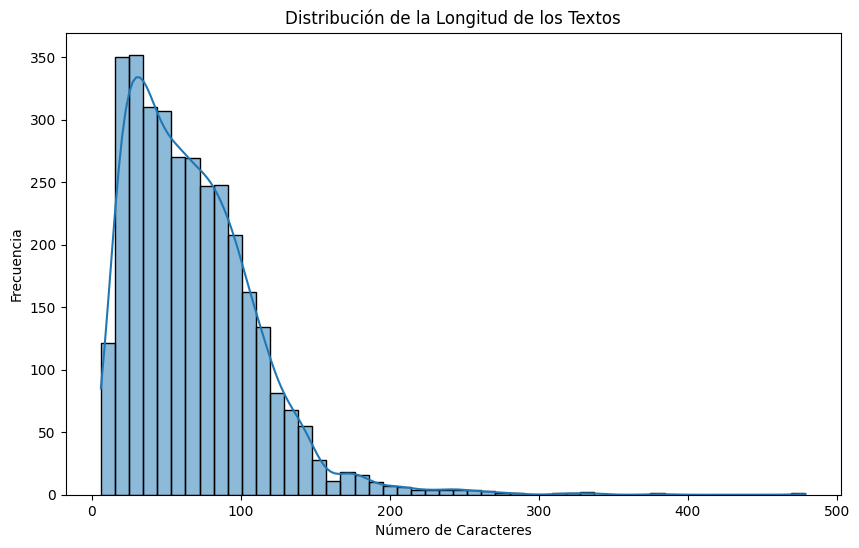

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['longitud_texto'], bins=50, kde=True)
plt.title('Distribución de la Longitud de los Textos')
plt.xlabel('Número de Caracteres')
plt.ylabel('Frecuencia')
plt.show()

Se observa que la mayoría de las palabras tienen entre 10 y 100 caracteres aproximadamente.

Para poder tener una mejor representación visual de las palabras, se debe realizar una limpieza del texto, así como eliminar las stopwords.



In [ ]:
pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
import nltk
import re
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import contractions

nltk.download('stopwords')
nltk.download('punkt')
nlp = spacy.load('en_core_web_sm')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def quitar_stopwords_y_puntuacion(texto):
  # Quitar caracteres especiales
  text = re.sub(r"[^a-zA-Z\s']", ' ', texto)
  # Quitar numeros
  text = re.sub(r'\d+', '', text)

  text = contractions.fix(text)
  tokens = word_tokenize(text)
  palabras_f = [palabra for palabra in tokens if palabra.lower() not in stop_words and len(palabra) > 2]
  return palabras_f

El dataframe sin stopwords solamente funciona para la visualización. En el entrenamiento y prueba de la red no es necesario ya que puede quitar contexto importante de las sentencias.

In [ ]:
df_sin_sw = df.copy()
df_sin_sw['sentence'] = df_sin_sw['sentence'].apply(quitar_stopwords_y_puntuacion)
df_sin_sw.head()

,sentence,sentiment,longitud_texto
0,"[way, plug, unless, converter]",negative,82
1,"[Good, case, Excellent, value]",positive,27
2,"[Great, jawbone]",positive,22
3,"[Tied, charger, conversations, lasting, minute...",negative,79
4,"[mic, great]",positive,17


Visualización de las palabras más comunes por sentimiento positivo.

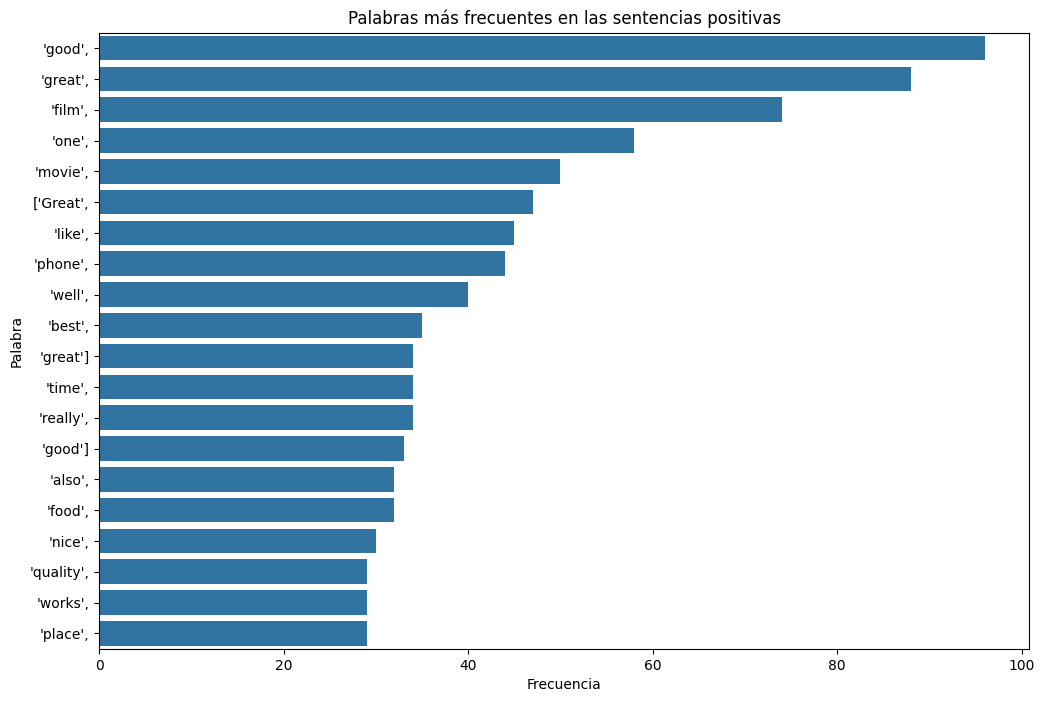

In [ ]:
from collections import Counter
import pandas as pd


sentencias_positivas = df_sin_sw[df_sin_sw['sentiment'] == 'positive']['sentence'].astype(str).str.cat(sep=' ')
palabras_positivas = sentencias_positivas.split()

conteo_positivas = Counter(palabras_positivas)
df_positivas = pd.DataFrame(conteo_positivas.most_common(20), columns=['Palabra', 'Frecuencia'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Frecuencia', y='Palabra', data=df_positivas)
plt.title('Palabras más frecuentes en las sentencias positivas')
plt.show()

Visualización de las palabras más comunes por sentimiento negativo.

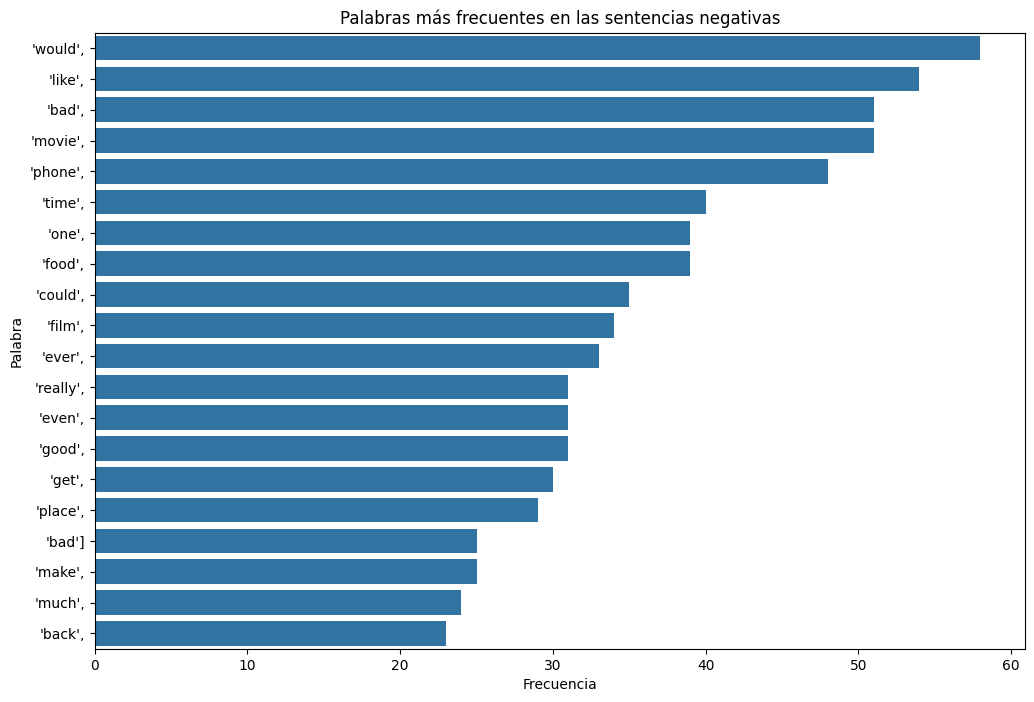

In [ ]:
from collections import Counter
import pandas as pd


sentencias_negativas = df_sin_sw[df_sin_sw['sentiment'] == 'negative']['sentence'].astype(str).str.cat(sep=' ')
palabras_negativas = sentencias_negativas.split()

conteo_negativas = Counter(palabras_negativas)
df_negativas = pd.DataFrame(conteo_negativas.most_common(20), columns=['Palabra', 'Frecuencia'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Frecuencia', y='Palabra', data=df_negativas)
plt.title('Palabras más frecuentes en las sentencias negativas')
plt.show()

## 2. Separar datos en entrenamiento y prueba

Una vez realizada la visualización, lo siguiente será realizar la separación en entrenamiento y prueba. Un estándar suele ser 80% datos para entrenamiento y 20% en prueba. Cabe recordar que se debe transformar las etiquetas positivas y negativas a un número.

In [ ]:
from sklearn.model_selection import train_test_split

df['sentiment_labels'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(df['sentence'],
                  df['sentiment_labels'], test_size = 0.2, random_state=42)

print("Longitud de X_train: ", X_train.shape)
print("Longitud de X_test:  ", X_test.shape)
print("Longitud de y_train: ", y_train.shape)
print("Longitud de y_test:  ", y_test.shape)

Longitud de X_train:  (2647,)
Longitud de X_test:   (662,)
Longitud de y_train:  (2647,)
Longitud de y_test:   (662,)


## 3. Preprocesamiento y embeddings

En la parte del preprocesamiento, únicamente se pretende realizar la conversión a minúsculas, quitar etiquetas y menciones (por si las hubiese) y aplicar lematización, así como la eliminación de corchetes. Esto con la finalidad de no perder significado en el texto para la clasificación.

In [ ]:
def preprocesamiento(text):
  text = re.sub(r'<.*?>', '', text)
  # Quitar URLs y menciones
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  # Quitar paréntesis, corchetes y llaves
  text = re.sub(r'[\[\]\(\)\{\}]', '', text)
  # Quitar dobles espacios
  text = re.sub(r'\s+', ' ', text).strip()

  text = text.lower()
  # Lematización y tokenización
  tokens = [token.lemma_ for token in nlp(text) if not token.is_stop and not token.is_punct]
  return tokens

In [ ]:
X_train = X_train.apply(preprocesamiento)
X_test = X_test.apply(preprocesamiento)

Aplicación tokenización.

Para la parte de tokenización, el vocabulario que se usa es de 10,000 palabras el cual es un estándar en muchos trabajos de la misma índole en inglés.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

Conversión a secuencias numéricas.

In [ ]:
X_train_sec = tokenizer.texts_to_sequences(X_train)
X_test_sec = tokenizer.texts_to_sequences(X_test)

Padding.

De acuerdo al análisis anterior, se hace uso de una longitud máxima de 200 caracteres.

In [ ]:
long_max = 200
X_train_pad = pad_sequences(X_train_sec, maxlen=long_max)
X_test_pad = pad_sequences(X_test_sec, maxlen=long_max)

Visualización de resultados.

In [ ]:
print("Tokens (entrenamiento):", X_train.iloc[0])
print("Secuencia de enteros (entrenamiento):", X_train_sec[0])
print("Secuencia con padding (entrenamiento):\n", X_train_pad[0])

print("\nFracción del vocbulario:", list(tokenizer.word_index.items())[:5])

Tokens (entrenamiento): ['waiter', 'attentive', 'friendly', 'informative']
Secuencia de enteros (entrenamiento): [368, 369, 79, 1859]
Secuencia con padding (entrenamiento):
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0

La parte de conversión de embeddings se ha realizado dentro de las épocas de entrenamiento.

## 3. Entrenamiento de la red

Anteriormente se mencionó que el vocabulario es de 10,000, por lo que para el entrenamiento se hará nuevamente uso de esta cantidad.

En la literatura, se recomienda que se haga uso de embeddings en potencias de 2. Como se vio anteriormente, el contexto promedio era entre 10 a 100 caracteres, por lo que se hace uso de una dimensión de 32 para que el modelo no se vuelva tan pesado y sea "rápido" de entrenar.

Al igual que la capa de embedding, se recomienda que la capa oculta sea mayor que la capa de embedding, nuevamente en potencia de 2. Con esta suposición, se hace uso de una dimensión de 64 para esta capa.

Recordando que la salida es una clasificación binaria, solamente tendrá 2 neuronas.

La tasa de aprendizaje es de 0.01 y el número de épocas se fijó a 20.

In [ ]:
VOCAB_SIZE = 10000
EMBEDDING_DIM = 32
HIDDEN_DIM = 64
OUTPUT_DIM = 2
EPOCHS = 20
ALPHA = 0.01

y_train_categorico = to_categorical(y_train, num_classes=OUTPUT_DIM)

rnn = SimpleRNN(
    random_init=True,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM
)

for epoch in range(EPOCHS):
    total_loss = 0
    num_muestras = len(X_train)
    for i in range(num_muestras):
        x_prueba_id = X_train_pad[i]
        y_true = y_train_categorico[i]

        y_pred = rnn.forward(x_prueba_id)
        loss = np.mean((y_pred - y_true)**2)
        total_loss += loss
        gradients = rnn.backward(y_true)
        rnn.update_weights(gradients, ALPHA)

    avg_loss = total_loss / num_muestras
    print(f"ÉPOCA {epoch + 1}/{EPOCHS}, Pérdida Promedio (MSE): {avg_loss:.4f}")


ÉPOCA 1/20, Pérdida Promedio (MSE): 0.2489
ÉPOCA 2/20, Pérdida Promedio (MSE): 0.2373
ÉPOCA 3/20, Pérdida Promedio (MSE): 0.2043
ÉPOCA 4/20, Pérdida Promedio (MSE): 0.2422
ÉPOCA 5/20, Pérdida Promedio (MSE): 0.2037
ÉPOCA 6/20, Pérdida Promedio (MSE): 0.1557
ÉPOCA 7/20, Pérdida Promedio (MSE): 0.1212
ÉPOCA 8/20, Pérdida Promedio (MSE): 0.1215
ÉPOCA 9/20, Pérdida Promedio (MSE): 0.0978
ÉPOCA 10/20, Pérdida Promedio (MSE): 0.0813
ÉPOCA 11/20, Pérdida Promedio (MSE): 0.0800
ÉPOCA 12/20, Pérdida Promedio (MSE): 0.0589
ÉPOCA 13/20, Pérdida Promedio (MSE): 0.0620
ÉPOCA 14/20, Pérdida Promedio (MSE): 0.0530
ÉPOCA 15/20, Pérdida Promedio (MSE): 0.0502
ÉPOCA 16/20, Pérdida Promedio (MSE): 0.0545
ÉPOCA 17/20, Pérdida Promedio (MSE): 0.0509
ÉPOCA 18/20, Pérdida Promedio (MSE): 0.0488
ÉPOCA 19/20, Pérdida Promedio (MSE): 0.0517
ÉPOCA 20/20, Pérdida Promedio (MSE): 0.0410


## Predicción

Finalmente, para la predicción, se hace uso de Accuracy para mostrar la exactitud del modelo.

In [ ]:
predicciones = []
for x_prueba_id in X_test_pad:
    y_pred_prob = rnn.forward(x_prueba_id)
    prediccion = np.argmax(y_pred_prob)
    predicciones.append(prediccion)

accuracy = accuracy_score(y_test, predicciones)
print(f"Exactitud (Accuracy): {accuracy * 100:.2f}%")

Exactitud (Accuracy): 77.64%


## Conclusión
A través de este proyecto se mostró que la precisión de la red neuronal construida desde cero fue aceptable. Con respecto a este ejercicio, se puede decir que es fundamental porque permite entender en detalle el funcionamiento de sus capas y operaciones. Esta aplicación permite realizar la modificación o crear arquitecturas de red más complejas en el futuro.